# Workshop 1: Plotting Astronomical Data

In this exercise, we will be using the tools we learned in **Lighthouse** to import and manipulate real astronomical data! We will use packages you're already familiar with, such as `numpy` and `matplotlib`, along with two new ones. We will use `psrqpy`, a package that allows us to access the Australian National Telescope Facility (ATNF) pulsar catalog, which contains information about pulsars. We will also use `pandas`, a common package for manipulating and analyzing data.  First, let's import these.

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import psrqpy

Now let's use the `psrqpy` package to import data about the pulsars in the catalog. We will get the following variables:

- `PSRJ`: The pulsar name in the J2000 coordinate system
- `P0`: The pulsar period in seconds (i.e. how long it takes for the pulsar to complete one rotation)
- `P1`: The pulsar period derivative in $\frac{\text{s}}{\text{s}}$ (i.e. how fast the period is changing over time)
- `BSURF`: The pulsar's surface magnetic field strength in Gauss
- `AGE`: The pulsar's age in seconds
- `S400`: The pulsar's flux density at 400 MHz in mJy (i.e. how "bright" the pulsar is on Earth at 400 MHz)
- `DM`: The pulsar's dispersion measure in $\frac{\text{pc}}{\text{cm}^{3}}$
- `DIST`: The pulsar's estimated distance in kpc
- `DATE`: The date of discovery observation
- `RAJD`: The pulsar's right ascension in J2000 coordinates (in degrees)
- `DECJD`: The pulsar's declination in J2000 coordinates (in degrees)
- `GL`: The pulsar's Galactic longitude (in degrees)
- `GB`: The pulsar's Galactic latitude (in degrees)

The code block below will import the data from the catalog's 4343 pulsars and store it in a `pandas` DataFrame.

In [165]:
# Define what you want to extract
query = psrqpy.QueryATNF(params=['PSRJ', 'P0', 'P1', 'BSURF', 'AGE', 'S400', "DM", "DIST", "DATE", "RAJD", "DECJD", "GL", "GB"])

# Fetch the data and save it as a pandas DataFrame
data = query.table.to_pandas()

Now, `data` is in the form of a `pandas` DataFrame. These work similarly to `numpy` arrays, but with additional functionality. Below is a quick overview of how to use them.

You can access the data in the DataFrame using the column names as keys. For example, to access the data in the `P0` column, you can use the following code:

In [51]:
# Get the periods by indexing the data array with the appropriate column name
periods = data['P0']

# Let's see what type of object we have
print(type(periods))

<class 'pandas.core.series.Series'>


We now have the variable `periods`, which is the periods of all of the pulsars in the form of a `pandas` Series. For our purposes, we can treat this the same as a `numpy` array.

In [66]:
# you can use all the fun tricks you learned for numpy arrays!
FirstElement = periods[0]
frequencies = 1 / periods
periodssquared = periods**2
#etc...


Now we'll quickly walk through making a classic plot in pulsar studies, the P-Pdot diagram. "P" stands for period, and "Pdot" stands for the time derivative of the period, which is just how fast the period is changing over time (it is called "Pdot" because in physics you typically will denote time derivatives with a dot above the variable, like $\dot{P}$). Now, use `plt.scatter` to make a scatter plot with the period `P0` on the x axis and the period derivative `P1` on the y axis. Don't forget to label your axes!

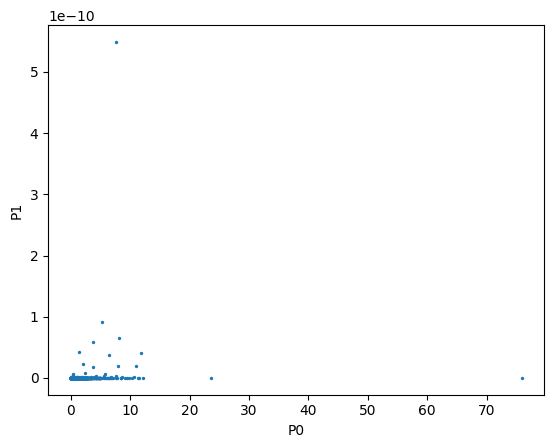

In [ ]:
plt.scatter(data['P0'], data['P1'], s=2)
plt.xlabel('P0')
plt.ylabel('P1')
plt.show()

Hmmm, so this looks a bit ugly. You should notice a large grouping of points in the bottom left, and a few scattered farther away. What's going on? Well, the values for `P0` and `P1` span multiple orders of magnitude. If you're not familiar, you can think of an order of magnitude as a rough way to compare how much bigger one number is than another, specifically in powers of 10. We can counteract this by taking the logarithm of this values, which works something like this:

- $\log_{10}(10) = 1$
- $\log_{10}(100) = 2$
- $\log_{10}(1000) = 3$

More generally, if $x = 10^y$, then $\log_{10}(x) = y$. Using this, we can rescale our graphs to make trends in the data easier to spot. This is a very common practice throughout science but especially astronomy, since the universe has structure over so many orders of magnitude.

Now, remake the plot, but use the `numpy` function `np.log10()` to take the base-10 logarithm of the values for `P0` and `P1`. Remember to change your axes accordingly!

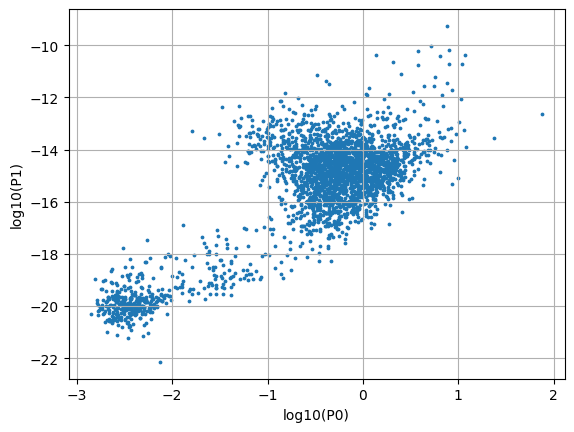

In [103]:
plt.scatter(np.log10(data['P0']), np.log10(data['P1']), s=3)
plt.xlabel('log10(P0)')
plt.ylabel('log10(P1)')
plt.grid(True)
plt.show()

Now you've made a P-Pdot diagram! You should see two distinct populations, one on the upper right (higher period and higher period derivative) and one smaller population on the lower left (lower period and lower period derivative). What does this tell us about pulsars?

Now, your task will be to find more trends among the data. One more tool that may be helpful is adding colors to the points on your scatter plot according to a third variable. For example, plotting a P-Pdot diagram where the dots are colored based on the magnetic field strength looks like this.

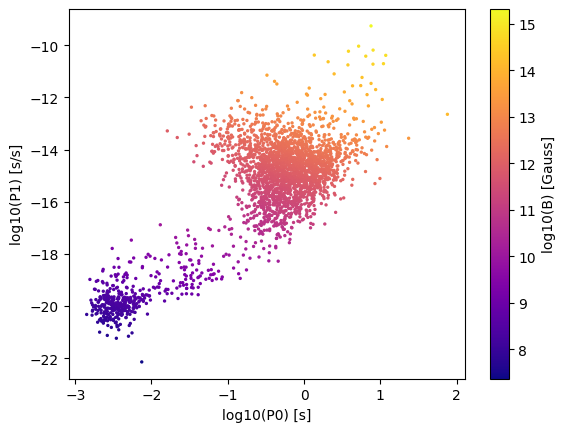

In [107]:
plt.scatter(np.log10(df['P0']), np.log10(df['P1']), c=(np.log10(df['BSURF'])), cmap='plasma', s=2)
plt.colorbar(label='log10(B) [Gauss]')
plt.xlabel('log10(P0) [s]')
plt.ylabel('log10(P1) [s/s]')
plt.show()



One more type of plot you may find useful is the histogram. Let's do a quick example using the dates pulsars were discovered. It takes the range of dates between the first year a pulsar discovery was published (1969) up until now (2025) and splits that range into some number of subranges called "bins". Then, it counts how many pulsars were discovered in each bin and plots that count as a bar on a graph. To make them, you can use `plt.hist(data, bins = N)` where `N` is the number of bins you want. You want to choose `N` to be large enough to see the distribution of data but not so large that the bars are too small to see. 

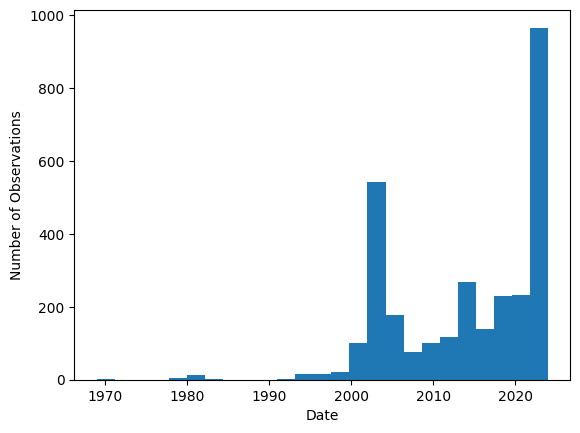

In [155]:
plt.hist(data["DATE"], bins = 25)
plt.xlabel("Date")
plt.ylabel("Number of Observations")
plt.show()

Now try out sone plots for yourself and see what you can find!

If you would like, here is a list of all of the pulsar properties you can import: https://www.atnf.csiro.au/research/pulsar/psrcat/